# Project Objective

## This analysis explores the Superstore sales dataset to understand:

### • What drives sales performance
### • Which product categories generate the most profit
### • How discounting affects profitability
### • Whether operational factors such as shipping mode influence order value

# Imports

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from datetime import datetime

%matplotlib inline

sns.set_style("whitegrid")


# Load Data

In [2]:
df = pd.read_csv("superstoreorders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [4]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

# Data Cleaning

### Converting dates

In [66]:
df["order_date"] =  pd.to_datetime(df["order_date"], dayfirst = True)
df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst = True)

# Feature Engineering

### Time Features

In [67]:
df["month"] = df['order_date'].dt.month
df["year"] =  df['order_date'].dt.year
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

### Profit Margin

In [68]:
df["sales"] = df["sales"].replace('[\?,]', '', regex = True)
df["sales"] = pd.to_numeric(df['sales'])

df["profit_margin"] = ((df["profit"] / df["sales"]) * 100).round(2)
df['profit_margin']

0        26.01
1        30.03
2        44.91
3       -57.90
4        33.13
         ...  
51285    32.28
51286    10.50
51287    47.54
51288     8.00
51289   -20.16
Name: profit_margin, Length: 51290, dtype: float64

# Exploratory Data Analysis

### Monthly Sales

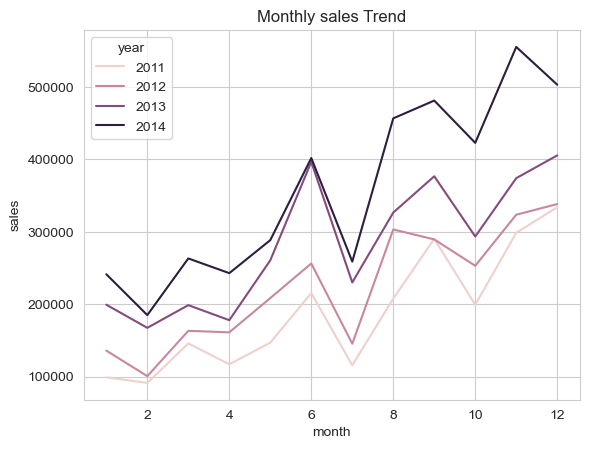

In [75]:
monthly_sales = df.groupby(["year","month"])["sales"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="month", y="sales", hue="year")
plt.title("Monthly sales Trend")
plt.savefig("month_sales.png", bbox_inches = "tight", dpi=300)
plt.show()

### Profit Margin By Category

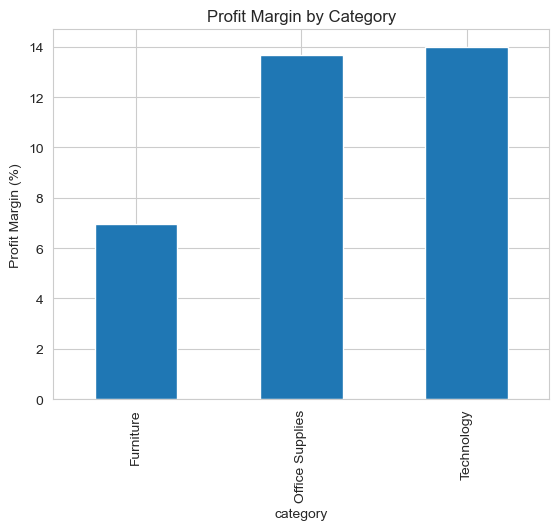

In [76]:
category_summary = df.groupby("category").agg(
    total_sales=("sales","sum"),
    total_profit=("profit","sum"),
    orders=("sales","count")
)

category_summary["profit_margin"] = category_summary["total_profit"] / category_summary["total_sales"]
(category_summary["profit_margin"]* 100).plot(kind="bar")

plt.title("Profit Margin by Category")
plt.ylabel('Profit Margin (%)')
plt.savefig("category_summary.png", bbox_inches = "tight", dpi = 300)
plt.show()

Technology and Office Supplies generate the strongest profit margins, both exceeding 13%, indicating these categories contribute the most to profitability relative to revenue. Furniture, however, produces significantly lower margins (~7%), suggesting higher operational costs or aggressive discounting strategies. This indicates potential opportunities to review pricing or discount policies within the Furniture category to improve profitability.

### Shipping mode analysis

#### Shipping time

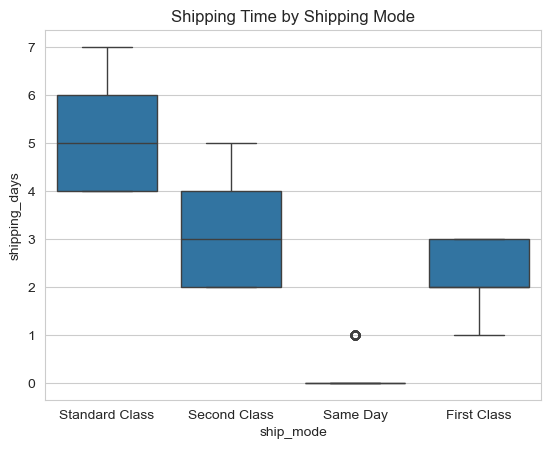

In [16]:
sns.boxplot(x="ship_mode", y="shipping_days", data=df)

plt.title("Shipping Time by Shipping Mode")
plt.savefig("shipping_time_by_mode.png", bbox_inches = "tight", dpi = 300)

plt.show()

Shipping Time Analysis

The visualisation illustrates the distribution of delivery times across the different shipping modes. Standard Class exhibits the longest delivery times, with a median of approximately five days and some orders taking up to seven days.

Second Class deliveries show a faster median delivery time of around three days, although some orders extend to approximately five days, indicating variability in fulfilment times.

First Class shipping demonstrates consistently faster delivery, with a median of roughly two to three days. The lower quartile suggests that approximately 25% of orders are delivered within one day, indicating that many first-class shipments are fulfilled very quickly.

These results confirm that the shipping mode categories align with their expected operational performance, with faster shipping options providing shorter and more consistent delivery times.

#### Shipping vs Profit

In [17]:
shipping_profit = df.groupby("ship_mode")[["sales","profit"]].sum()

shipping_profit["profit_margin"] = shipping_profit["profit"] / shipping_profit["sales"]

shipping_profit

,sales,profit,profit_margin
ship_mode,,,
First Class,1831067,208104.67520,0.113652
Same Day,667202,76173.06780,0.114168
Second Class,2565747,294161.05708,0.114649
Standard Class,7578889,890596.02120,0.117510


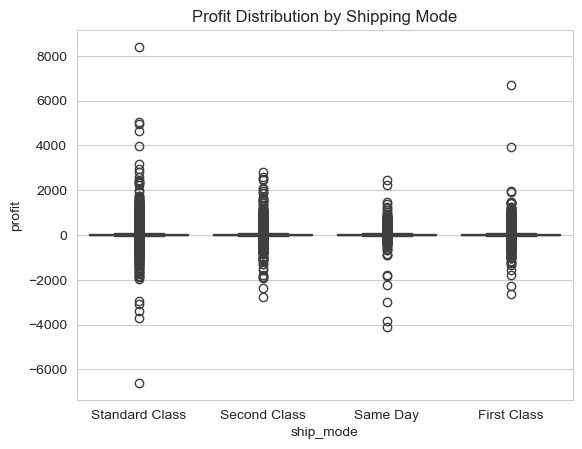

In [77]:
shipping_summary = df.groupby("ship_mode")[["sales","profit"]].sum()

shipping_summary["margin"] = shipping_summary["profit"] / shipping_summary["sales"]
sns.boxplot(x="ship_mode", y="profit", data=df)
plt.title("Profit Distribution by Shipping Mode")
plt.savefig("profit_distribution_shipping_mode.png", bbox_inches = "tight", dpi = 300)
plt.show()

Standard Class shipping exhibits the longest delivery times, with a median of approximately five days, while First Class, Second Class, and Same Day options provide significantly faster fulfilment.

Despite these differences in delivery speed, profitability across the various shipping modes appears to have similar median values. This suggests that the choice of shipping method is not strongly associated with the profitability of individual orders.

Standard Class does show slightly higher overall profit dispersion, likely due to its higher order volume rather than inherently more profitable transactions. This may indicate that customers often select Standard Class for larger or less time-sensitive purchases where delivery speed is not a priority

Further analysis comparing order value (sales) by shipping mode could determine whether faster shipping is associated with higher-value purchases.

#### These results confirm that the shipping mode categories align with their expected operational performance, with faster shipping options providing shorter and more consistent delivery times.

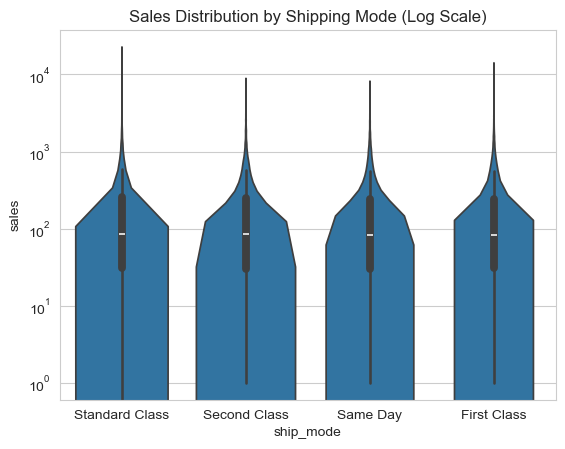

In [22]:
sns.violinplot(x="ship_mode", y="sales", data=df)

plt.yscale("log")
plt.title("Sales Distribution by Shipping Mode (Log Scale)")
plt.savefig("sales_distribution_shipping_mode_log.png", bbox_inches = "tight", dpi = 300)
plt.show()

The violin plot illustrates the distribution of order values across different shipping modes. The width of the violins indicates where most transactions occur. Across all shipping modes, most orders cluster within a similar range of lower to mid-value purchases. Standard Class displays the widest distribution, suggesting greater variability in order values and likely reflecting its higher transaction volume. High-value outliers appear across multiple shipping modes, indicating that expensive purchases are not limited to faster delivery options.

### Profit Analysis

#### Profit Distribution

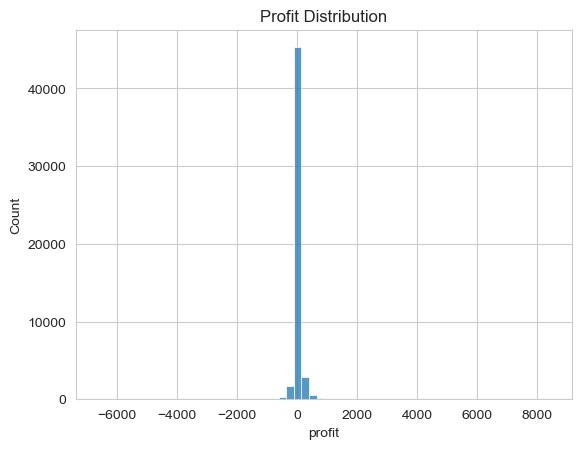

In [74]:
sns.histplot(df["profit"], bins=60, kde = False)
plt.title("Profit Distribution")
plt.savefig("profit_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

#### Profit vs Discount

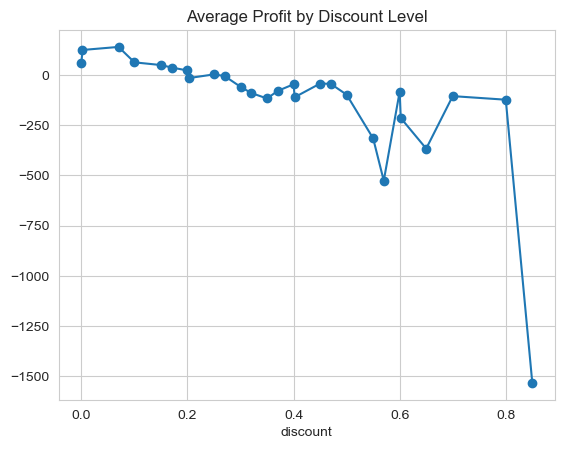

In [78]:
df.groupby("discount")["profit"].mean().plot(marker="o")
plt.title("Average Profit by Discount Level")
plt.savefig("average_profit_by_discount.png", bbox_inches = "tight", dpi = 300)
plt.show()

The chart shows that average profit declines as discount levels increase. Orders with little or no discount generate the highest profits, while higher discount levels are associated with significantly lower profitability. At larger discounts, average profit often becomes negative, indicating loss-making transactions. This suggests that although discounts may increase sales volume, excessive discounting can erode margins and reduce overall profitability.

#### Correlation Heatmap

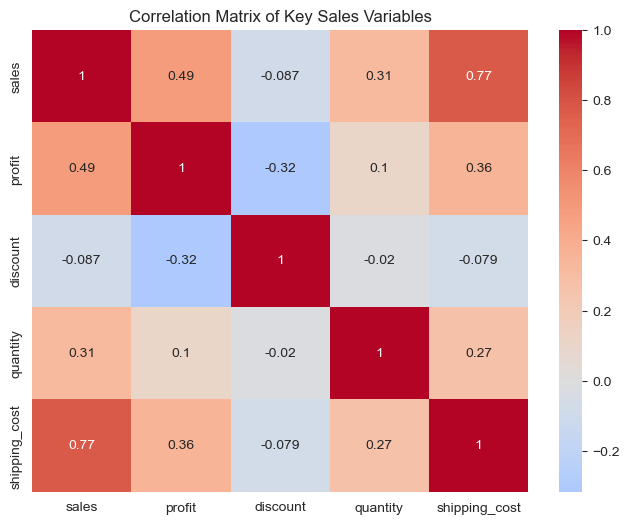

In [80]:
corr = df[["sales","profit","discount","quantity","shipping_cost"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, 
            annot=True, 
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix of Key Sales Variables")
plt.savefig("correlation_matrix_sales_variable.png", bbox_inches = "tight", dpi = 300)
plt.show()

The correlation matrix highlights several relationships between key variables. The strong correlation between sales and shipping cost (0.77) suggests that shipping cost acts as a proxy for order size. Larger transactions naturally incur higher shipping costs, which explains why shipping cost also shows a positive relationship with profit in the regression model. Profit shows a moderate positive relationship with sales (0.49), indicating that larger orders generally contribute to higher profits. Notably, discount displays a negative correlation with profit (-0.32), reinforcing earlier findings that higher discount levels reduce profitability. Other variables such as quantity show only weak relationships with profit, suggesting that order size alone does not strongly determine profit outcomes.

#### Multiple Linear Regression

In [60]:
X = pd.get_dummies(df[["discount","quantity","shipping_cost","category"]], drop_first=True)
y = df["profit"]
model = LinearRegression()
model.fit(X, y)
print(model.coef_, model.intercept_)


[-236.63549772    0.70631769    1.00716867   12.18428234   23.26416164] 21.409323422075957


A linear regression model was used to examine the relationship between profit and several predictors including discount, quantity sold, and shipping cost. The results indicate a strong negative relationship between discount levels and profit, suggesting that higher discounts significantly reduce profitability. In contrast, quantity sold and shipping cost show positive associations with profit, implying that larger orders and higher-value shipments tend to generate greater profit.

In [48]:
pred =  model.predict(X)
r2_score(y, pred)

0.21281972649683922

The regression model explains approximately 21% of the variation in profit, indicating that discount, quantity sold, and shipping cost contribute to profitability but do not fully explain it. This suggests that other factors such as product category, pricing structure, or market conditions may also influence profit outcomes.

#### Standardised coefficients

In [61]:
X = df[["discount","quantity","shipping_cost"]]
y = df["profit"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print(model.coef_)

[-50.57832772   1.48576906  57.87103081]


Standardisation was applied to the independent variables to ensure that each feature was measured on a comparable scale. By transforming variables such as discount, quantity, and shipping cost into standardised units, the regression coefficients can be interpreted more reliably when comparing their relative influence on profit. This allows us to identify which variables have the strongest effect on the model outcome.

#### Residual diagnostics

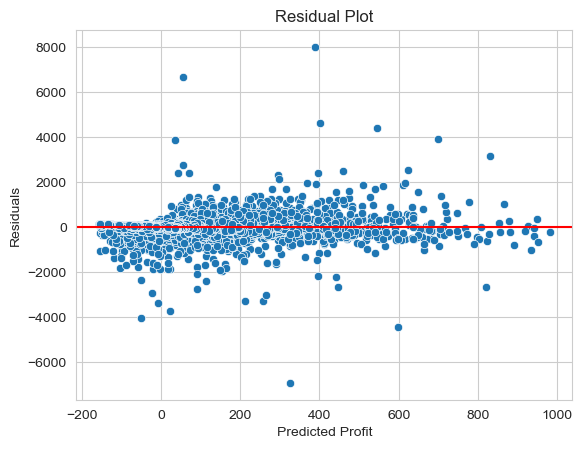

In [81]:
pred = model.predict(X_scaled)
residuals = y - pred

sns.scatterplot(x=pred, y=residuals)

plt.axhline(0, color="red")
plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_plot.png", bbox_inches = "tight", dpi = 300)
plt.show()

Standardisation was applied to the independent variables to ensure that each feature was measured on a comparable scale. By transforming variables such as discount, quantity, and shipping cost into standardised units, the regression coefficients can be interpreted more reliably when comparing their relative influence on profit. This allows us to identify which variables have the strongest effect on the model outcome.

#### Visual regression relationship

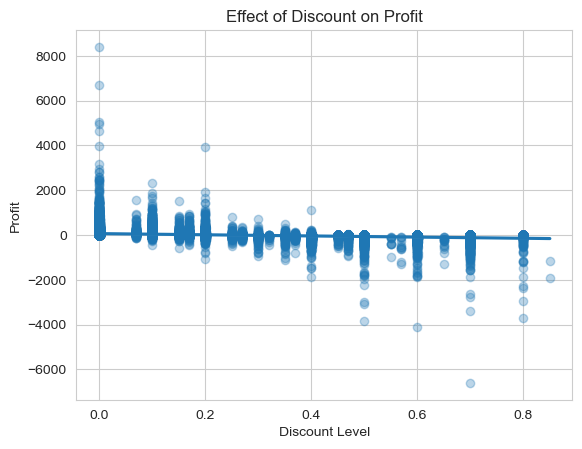

In [82]:
sns.regplot(x="discount", y="profit", data=df, scatter_kws={"alpha":0.3})

plt.title("Effect of Discount on Profit")
plt.xlabel("Discount Level")
plt.ylabel("Profit")
plt.savefig("discount_profit_regression.png", bbox_inches = "tight", dpi = 300)
plt.show()

### Profit Analysis Key Findings: 

##### 1. Discounting strongly reduces profit and is associated with many loss-making orders.
##### 2. Technology and Office Supplies generate higher average profits than Furniture.
##### 3. Standard Class accounts for the majority of orders but does not significantly affect order value.
##### 4. Regression analysis confirms that discount is the strongest negative predictor of profit.

## Final Conclusions

The analysis explored the Superstore dataset to understand key drivers of sales performance and profitability. Initial exploratory analysis revealed that while overall sales are distributed across multiple product categories and shipping modes, profitability varies considerably between transactions.

A key finding from the operational analysis is that shipping mode has limited influence on order value, with most purchases occurring through Standard Class delivery due to its higher transaction volume rather than higher-value orders.

The profit analysis highlights that discounting plays a critical role in determining profitability. Visual analysis and regression modelling both demonstrate a negative relationship between discount levels and profit, with higher discount rates frequently associated with loss-making transactions.

Further statistical analysis using multiple linear regression confirms that discount has the strongest negative influence on profit, while variables such as quantity and shipping cost show smaller positive relationships with profitability.

Overall, the results suggest that while discounts may help stimulate sales, aggressive discounting strategies can significantly erode profit margins. Careful management of pricing and promotional strategies is therefore essential to maintain sustainable profitability.